# Protograph anchoring — a $\lambda$ sweep (DLCC synthetic tc01–tc15, excl. tc04)

**Variant: anchor on the last epoch too.** This is the
last-epoch-*inclusive* version of the $\lambda$ sweep — the proximal pull-back is
applied after **every** fine-tune epoch, the final one included. Outputs are
written to `notebooks/anchoring/anchor_last_epoch/` so the original
"anchor every epoch *but* the last" thesis artifacts are preserved.

### What anchoring does

The protograph transfer pretrains skip-gram on a protograph (P1/P2/P3), then
seeds every typed instance from the pretrained codes of its classes — a
*schema-informed* starting point $\mathbf{v}^0_e$. During instance-level
fine-tuning those embeddings drift away from $\mathbf{v}^0_e$. **Anchoring**
counteracts the drift with an L2 penalty toward the initialization,

$$\mathcal{L}_{total}=\mathcal{L}_{RDF2Vec}+\lambda\!\!\sum_{e\in E_{anchored}}\!\!\lVert\mathbf{v}_e-\mathbf{v}^0_e\rVert_2^2 .$$

We realize it as the closed-form proximal step of that penalty, applied **at the
end of every fine-tune epoch, the last one included**:

$$\mathbf{v}_e \leftarrow (1-\lambda)\,\mathbf{v}_e + \lambda\,\mathbf{v}^0_e .$$

i.e. each class-initialized instance is pulled a fraction $\lambda$ of the way
back to its class embedding after **every** epoch. **Unlike the default
`InstanceAnchoringCallback`, the final epoch is no longer exempt** — so the saved
model's anchored instances are pulled toward their class init *before* being
frozen. $\lambda=0$ recovers the plain transfer; $\lambda=1$ hard-resets the
anchored instances to their initialization after every epoch including the last,
so the saved anchored vectors equal their class init exactly.

### Experimental design — normal classic transfer at the *default* LR

Anchoring is only meaningful where the model actually **drifts** from its init.
An earlier version of this sweep used the project's *protected* finetune LR
`0.0025`, under which the embeddings barely move from epoch 0 — so anchoring had
almost nothing to regularize and could only ever slow the little useful learning
that occurred. That protected sweep is preserved under
`notebooks/anchoring/protected_lr0025_backup/`.

This version keeps the **normal classic transfer recipe** and changes only the
finetune LR, so anchoring is tested where there *is* real drift to pull back:

* **TC set** — the 14 synthetic DLCC test cases `tc01`–`tc15` **excluding `tc04`**
  (its instance-walk corpus is ~20× the others — a near-trivial existence task
  that costs ~1.5 h on its own; the `p3_classic` experiment excludes it too).
* **Default finetune LR `0.025`** (gensim default, identical to the from-scratch
  `vanilla` rate, decaying to `0.0001`) — the *only* change from the protected
  sweep. At `0.025` the transfer un-freezes and the codes actually move.
* **Normalized init, as in normal classic training** — `normalize=True`: the
  pretrained codes are L2-normalized to one shared scale (`TARGET_NORM=8`),
  exactly like the real `p1`/`p2`/`p3` classic runs, plus the `syn1neg` mirror.
  `dim=200`, 100 instance walks/entity, 200 protograph walks/entity, depth 3,
  5 pretrain + 5 finetune epochs, `seed=42`.
* **Same init rule — `most_specific` (the default) on all three protographs.**
  Every typed instance is seeded from the mean of its **most-specific** asserted
  class codes (no ancestor fallback); P1/P2/P3 differ only in the protograph the
  codes are pretrained on. Anchoring is strategy-agnostic: it anchors exactly the
  instances that received a class-based init.
* **Only moving part** — $\lambda\in\{0,0.1,0.25,0.5,0.75,1.0\}$.

For efficiency the protograph is pretrained **once** per (test case,
protograph); only the fine-tune is repeated per $\lambda$. A from-scratch
`vanilla` model and the un-anchored transfer ($\lambda=0$) are the reference
anchors.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd

ROOT = Path("..").resolve()
SCRIPTS = ROOT / "scripts"
if str(SCRIPTS) not in sys.path:
    sys.path.insert(0, str(SCRIPTS))

from _anchoring import (  # noqa: E402
    ALL_TCS, CFG, LAMBDAS, OUT_ROOT, PROTO_STRATEGY, PROTOGRAPHS,
    load_results, run_all, tc_paths,
)

# Sanity-check that every TC has its data on disk.
missing = [tc for tc in ALL_TCS for k, p in tc_paths(tc).items()
           if k != "walk_dir" and not Path(p).is_file()]
assert not missing, f"missing data files: {missing}"

print(f"Output root : {OUT_ROOT}")
print(f"TC set      : {', '.join(ALL_TCS)}")
print(f"Protographs : {', '.join(PROTOGRAPHS)}")
print(f"Init rule   : {PROTO_STRATEGY}")
print(f"Lambdas     : {LAMBDAS}")
print("Budget      :", {k: CFG[k] for k in
      ('dim', 'walks_per_entity', 'depth', 'epochs', 'pretrain_epochs',
       'finetune_alpha', 'min_alpha', 'normalize', 'target_norm', 'seed')})

Output root : /home/bnukhkadiev/Knowledge-Graphs/notebooks/anchoring/anchor_last_epoch
TC set      : tc01, tc02, tc03, tc05, tc06, tc07, tc08, tc09, tc10, tc11, tc12, tc13, tc14, tc15
Protographs : p1, p2, p3
Init rule   : {'p1': 'most_specific', 'p2': 'most_specific', 'p3': 'most_specific'}
Lambdas     : [0.0, 0.1, 0.25, 0.5, 0.75, 1.0]
Budget      : {'dim': 200, 'walks_per_entity': 100, 'depth': 3, 'epochs': 5, 'pretrain_epochs': 5, 'finetune_alpha': 0.025, 'min_alpha': 0.0001, 'normalize': True, 'target_norm': 8.0, 'seed': 42}


## Run (or load) the sweep

`run_all()` trains, per test case, `vanilla` plus the **6 $\lambda$ values × {P1,
P2, P3}** = 19 models and caches the result rows to
`notebooks/anchoring/results.json` (re-running only fills in missing test cases;
delete the JSON to force a full re-run, ≈ 3 h on this machine). All three
protographs use the default `most_specific` init rule with normalized codes
(`normalize=True`, `TARGET_NORM=8`, as in normal classic training) at the default
finetune LR `0.025` — see the design notes above.

In [2]:
results = run_all()  # cached after the first run
n_variants = {tc: len(rows) for tc, rows in results.items()}
print(f"{len(results)} test cases, variants each:", sorted(set(n_variants.values())))

tc01:


  [  20.4s]            vanilla  [0.500 0.912 0.958 0.945 0.950 0.943]


  [  48.5s]         p1_lambda0  [0.512 0.943 0.945 0.927 0.953 0.938]


  [  74.2s]       p1_lambda0.1  [0.512 0.932 0.943 0.950 0.943 0.950]


  [  99.7s]      p1_lambda0.25  [0.512 0.935 0.940 0.955 0.953 0.955]


...

  [ 589.9s]      p3_lambda0.25  [0.500 0.544 0.549 0.566 0.566 0.562]


  [ 626.4s]       p3_lambda0.5  [0.500 0.561 0.532 0.541 0.535 0.524]


  [ 662.7s]      p3_lambda0.75  [0.500 0.534 0.532 0.501 0.512 0.517]


  [ 698.8s]         p3_lambda1  [0.500 0.500 0.500 0.500 0.500 0.500]


14 test cases, variants each: [19]


## Build the data frame

For every result row we recover:

* **`final_acc`** — LogReg test accuracy after the 5th finetune epoch;
* **`init_acc`** — accuracy at epoch 0 (identical across $\lambda$ for a given
  protograph, since anchoring only acts *during* finetuning);
* **`best_acc`** — best accuracy over the 5 epochs;
* **`n_anchored`** — number of instances pulled back toward their class init.

In [3]:
recs = []
for tc, rows in results.items():
    for r in rows:
        if r["variant"] == "vanilla":
            recs.append(dict(tc=tc, proto="vanilla", lam=np.nan, variant="vanilla",
                             init_acc=r["accs"][0], final_acc=r["final_acc"],
                             best_acc=max(r["accs"]), n_anchored=0))
        else:
            recs.append(dict(tc=tc, proto=r["proto"], lam=r["lam"], variant=r["variant"],
                             init_acc=r["accs"][0], final_acc=r["final_acc"],
                             best_acc=max(r["accs"]), n_anchored=r["n_anchored"]))
df = pd.DataFrame(recs).sort_values(["tc", "proto", "lam"]).reset_index(drop=True)
df.head(19)  # one full test case: vanilla + 6 lambdas x {P1, P2, P3}

,tc,proto,lam,variant,init_acc,final_acc,best_acc,n_anchored
0,tc01,p1,0.00,p1_lambda0,0.5125,0.9375,0.9525,5543
1,tc01,p1,0.10,p1_lambda0.1,0.5125,0.9500,0.9500,5543
2,tc01,p1,0.25,p1_lambda0.25,0.5125,0.9550,0.9550,5543
3,tc01,p1,0.50,p1_lambda0.5,0.5125,0.9350,0.9475,5543
4,tc01,p1,0.75,p1_lambda0.75,0.5125,0.8625,0.9325,5543
5,tc01,p1,1.00,p1_lambda1,0.5125,0.6400,0.6675,5543
6,tc01,p2,0.00,p2_lambda0,0.5300,0.9550,0.9550,8523
7,tc01,p2,0.10,p2_lambda0.1,0.5300,0.9475,0.9475,8523
8,tc01,p2,0.25,p2_lambda0.25,0.5300,0.9400,0.9550,8523
9,tc01,p2,0.50,p2_lambda0.5,0.5300,0.9150,0.9300,8523


## Final accuracy per $\lambda$

One pivot per protograph: rows are test cases, columns the six $\lambda$ values,
the `vanilla` anchor alongside, and the bottom row is the mean over all 14 test
cases (tc01–tc15 excl. tc04).

In [4]:
vanilla_final = df[df.proto == "vanilla"].set_index("tc")["final_acc"]

def acc_pivot(proto, value="final_acc"):
    sub = df[df.proto == proto].pivot(index="tc", columns="lam", values=value)
    sub = sub[LAMBDAS]
    sub.insert(0, "vanilla", vanilla_final)
    sub = sub.reindex(ALL_TCS)
    sub.loc["mean"] = sub.mean()
    return sub.round(3)

for proto in PROTOGRAPHS:
    print(f"\n=== {proto.upper()} — final LogReg test accuracy (epoch 5) by lambda ===")
    display(acc_pivot(proto))


=== P1 — final LogReg test accuracy (epoch 5) by lambda ===


lam,vanilla,0.0,0.1,0.25,0.5,0.75,1.0
tc,,,,,,,
tc01,0.942,0.938,0.950,0.955,0.935,0.862,0.640
tc02,0.842,0.875,0.870,0.865,0.835,0.755,0.658
tc03,0.930,0.935,0.925,0.922,0.895,0.822,0.692
tc05,0.830,0.935,0.930,0.942,0.940,0.918,0.920
tc06,0.982,0.985,0.985,0.988,0.972,0.922,0.735
tc07,0.570,0.555,0.570,0.565,0.550,0.560,0.522
tc08,0.610,0.582,0.592,0.550,0.555,0.565,0.565
tc09,0.642,0.620,0.582,0.580,0.578,0.575,0.515
tc10,0.638,0.660,0.678,0.648,0.640,0.600,0.552



=== P2 — final LogReg test accuracy (epoch 5) by lambda ===


lam,vanilla,0.0,0.1,0.25,0.5,0.75,1.0
tc,,,,,,,
tc01,0.942,0.955,0.948,0.940,0.915,0.840,0.575
tc02,0.842,0.862,0.848,0.850,0.805,0.685,0.495
tc03,0.930,0.925,0.925,0.918,0.908,0.765,0.550
tc05,0.830,0.948,0.945,0.942,0.935,0.928,0.932
tc06,0.982,0.980,0.982,0.982,0.968,0.892,0.572
tc07,0.570,0.495,0.535,0.515,0.535,0.507,0.490
tc08,0.610,0.555,0.578,0.565,0.545,0.530,0.528
tc09,0.642,0.628,0.640,0.615,0.625,0.590,0.532
tc10,0.638,0.620,0.625,0.618,0.615,0.592,0.495



=== P3 — final LogReg test accuracy (epoch 5) by lambda ===


lam,vanilla,0.0,0.1,0.25,0.5,0.75,1.0
tc,,,,,,,
tc01,0.942,0.958,0.945,0.948,0.928,0.788,0.538
tc02,0.842,0.868,0.840,0.830,0.772,0.592,0.468
tc03,0.930,0.925,0.918,0.918,0.860,0.738,0.492
tc05,0.830,0.930,0.935,0.948,0.950,0.938,0.938
tc06,0.982,0.988,0.985,0.982,0.970,0.848,0.490
tc07,0.570,0.570,0.575,0.550,0.542,0.510,0.490
tc08,0.610,0.558,0.520,0.545,0.528,0.498,0.460
tc09,0.642,0.625,0.645,0.628,0.598,0.568,0.528
tc10,0.638,0.670,0.658,0.632,0.645,0.570,0.490


## Aggregate summary

The headline numbers exported to the thesis: mean (over all 14 TCs, tc01–tc15
excl. tc04) accuracy at init, best epoch, and final epoch for each $\lambda$ on
each protograph, with the $\Delta$ in final accuracy relative to the un-anchored
transfer ($\lambda=0$).

In [5]:
def summary_table():
    rows = []
    v = df[df.proto == "vanilla"]
    rows.append(dict(proto="-", lam=np.nan, init_acc=v.init_acc.mean(),
                     best_acc=v.best_acc.mean(), final_acc=v.final_acc.mean(), delta=np.nan))
    for proto in PROTOGRAPHS:
        base = df[(df.proto == proto) & (df.lam == 0.0)].final_acc.mean()
        for lam in LAMBDAS:
            s = df[(df.proto == proto) & (df.lam == lam)]
            rows.append(dict(proto=proto.upper(), lam=lam,
                             init_acc=s.init_acc.mean(), best_acc=s.best_acc.mean(),
                             final_acc=s.final_acc.mean(), delta=s.final_acc.mean() - base))
    return pd.DataFrame(rows)

summary = summary_table()
display(summary.round(4))

,proto,lam,init_acc,best_acc,final_acc,delta
0,-,NaN,0.4876,0.7268,0.7138,NaN
1,P1,0.00,0.5625,0.7552,0.7464,0.0000
2,P1,0.10,0.5625,0.7548,0.7474,0.0009
3,P1,0.25,0.5625,0.7473,0.7397,-0.0067
4,P1,0.50,0.5625,0.7430,0.7301,-0.0163
5,P1,0.75,0.5625,0.7282,0.7071,-0.0394
6,P1,1.00,0.5625,0.6563,0.6492,-0.0973
7,P2,0.00,0.5591,0.7471,0.7407,0.0000
8,P2,0.10,0.5591,0.7533,0.7437,0.0030
9,P2,0.25,0.5591,0.7485,0.7381,-0.0025


## Plot — mean accuracy vs $\lambda$ (P1, P2, P3)

All three protograph transfers on one axes (`new_anchoring.png`): mean final
LogReg test accuracy as a function of the anchoring strength $\lambda$, with the
from-scratch `vanilla` baseline drawn as a horizontal reference.

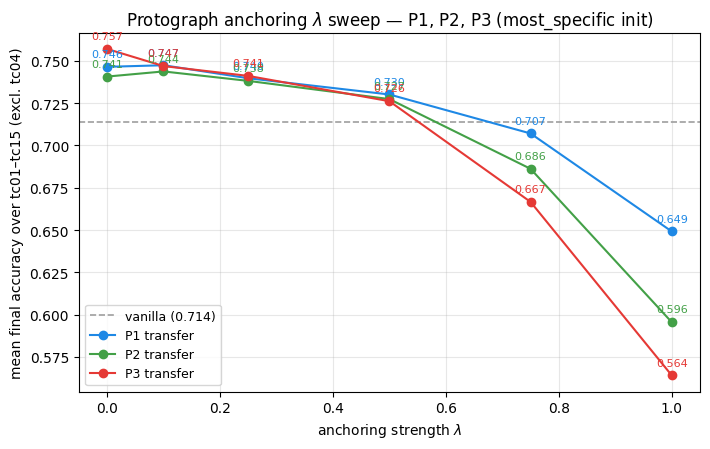

In [6]:
import matplotlib.pyplot as plt

PROTO_COLOR = {"p1": "#1e88e5", "p2": "#43a047", "p3": "#e53935"}

# All three protograph transfers on one axes: mean final accuracy vs lambda,
# with the from-scratch vanilla baseline as a horizontal reference.
fig, ax = plt.subplots(figsize=(7.2, 4.6))
vmean = vanilla_final.mean()
ax.axhline(vmean, color="#9e9e9e", ls="--", lw=1.2, label=f"vanilla ({vmean:.3f})")
for proto in PROTOGRAPHS:
    means = [df[(df.proto == proto) & (df.lam == lam)].final_acc.mean() for lam in LAMBDAS]
    ax.plot(LAMBDAS, means, marker="o", color=PROTO_COLOR[proto], label=f"{proto.upper()} transfer")
    for x, y in zip(LAMBDAS, means):
        ax.annotate(f"{y:.3f}", (x, y), textcoords="offset points", xytext=(0, 7),
                    ha="center", fontsize=8, color=PROTO_COLOR[proto])
ax.set_xlabel(r"anchoring strength $\lambda$")
ax.set_ylabel("mean final accuracy over tc01–tc15 (excl. tc04)")
ax.set_title("Protograph anchoring $\\lambda$ sweep — P1, P2, P3 (most_specific init)")
ax.grid(True, alpha=0.3)
ax.legend(loc="lower left", fontsize=9)
fig.tight_layout()
fig.savefig(OUT_ROOT / "new_anchoring.png", dpi=150, bbox_inches="tight")
plt.show()

## Per-epoch dynamics

Anchoring acts between epochs, so its effect is clearest in the epoch curves.
For a representative test case we overlay the accuracy trajectory for every
$\lambda$. At the default LR the un-anchored ($\lambda=0$) curve shows how far the
finetune drifts from the schema-informed init; larger $\lambda$ repeatedly pulls
the embedding back toward that init — which *helps* when the init is already good
and the finetune erodes it, and *hurts* when the init carries no task signal and
the finetune is what supplies it.

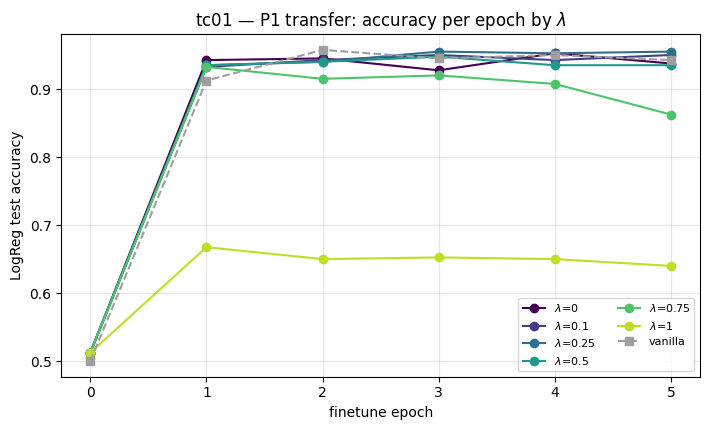

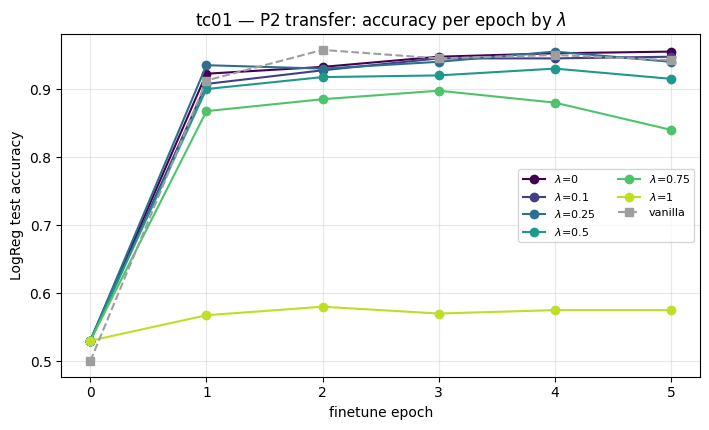

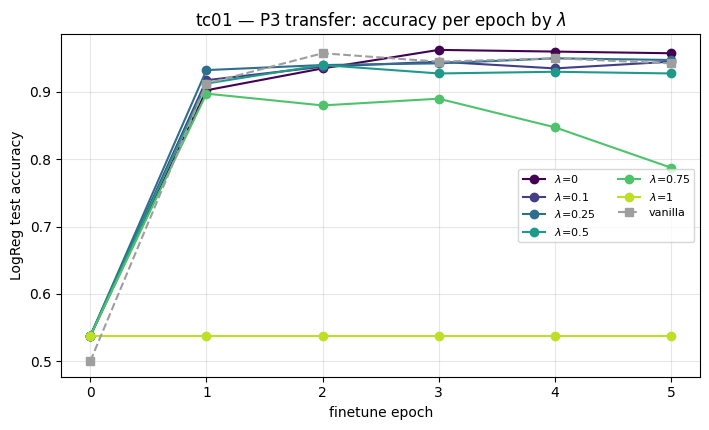

In [7]:
def epoch_curves(tc, proto):
    rows = {r["variant"]: r for r in results[tc]}
    fig, ax = plt.subplots(figsize=(7.2, 4.4))
    cmap = plt.cm.viridis(np.linspace(0, 0.9, len(LAMBDAS)))
    for lam, c in zip(LAMBDAS, cmap):
        accs = rows[f"{proto}_lambda{lam:g}"]["accs"]
        ax.plot(range(len(accs)), accs, marker="o", color=c, label=f"$\\lambda$={lam:g}")
    van = rows["vanilla"]["accs"]
    ax.plot(range(len(van)), van, marker="s", color="#9e9e9e", ls="--", label="vanilla")
    ax.set_xlabel("finetune epoch")
    ax.set_ylabel("LogReg test accuracy")
    ax.set_title(f"{tc} — {proto.upper()} transfer: accuracy per epoch by $\\lambda$")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8, ncol=2)
    fig.tight_layout()
    fig.savefig(OUT_ROOT / f"anchoring_epoch_curves_{tc}_{proto}.png", dpi=150, bbox_inches="tight")
    plt.show()

for proto in PROTOGRAPHS:
    epoch_curves("tc01", proto)

## Robustness check — per-TC, where does anchoring help or hurt?

The mean over the 14 test cases can hide strong per-TC heterogeneity (anchoring
should help where the classic init already carries the task signal and the
default-LR finetune erodes it, and hurt where the init is uninformative and the
finetune is what supplies the signal). Because all $\lambda$ variants of a test
case share the same pretrained protograph, the same initialization and the same
walk corpus, a **paired** per-TC comparison against $\lambda=0$ is the right
check: on how many test cases does each $\lambda$ win, and how large are the
gains vs the losses?

In [8]:
rows = []
for proto in PROTOGRAPHS:
    base = df[(df.proto == proto) & (df.lam == 0.0)].set_index("tc").final_acc
    for lam in LAMBDAS[1:]:
        cur = df[(df.proto == proto) & (df.lam == lam)].set_index("tc").final_acc
        d = (cur - base).reindex(ALL_TCS)
        rows.append(dict(proto=proto.upper(), lam=lam,
                         wins=int((d > 0).sum()), ties=int((d == 0).sum()),
                         losses=int((d < 0).sum()), mean_delta=d.mean(),
                         max_gain=d.max(), gain_tc=d.idxmax(),
                         max_loss=d.min(), loss_tc=d.idxmin()))
check = pd.DataFrame(rows)
display(check.round(4))

print("Per-TC gains > 0.02 over lambda=0:")
for proto in PROTOGRAPHS:
    base = df[(df.proto == proto) & (df.lam == 0.0)].set_index("tc").final_acc
    for lam in LAMBDAS[1:]:
        cur = df[(df.proto == proto) & (df.lam == lam)].set_index("tc").final_acc
        d = (cur - base).reindex(ALL_TCS)
        for tc, v in d[d > 0.02].items():
            print(f"  {proto} {tc} lam={lam:g}: {base[tc]:.3f} -> {cur[tc]:.3f} ({v:+.3f})")

# tc14 sanity: the transfers solve it perfectly already at initialization,
# so it is insensitive to lambda by construction (anchoring pulls toward an
# already-perfect init).
print("\ntc14 epoch curves (vanilla vs lambda=0 transfers):")
for row in results["tc14"]:
    if row["variant"] in ("vanilla", "p1_lambda0", "p2_lambda0", "p3_lambda0"):
        print(f"  {row['variant']:>12}: {[round(a, 3) for a in row['accs']]}")

,proto,lam,wins,ties,losses,mean_delta,max_gain,gain_tc,max_loss,loss_tc
0,P1,0.10,8,1,5,0.0009,0.0175,tc10,-0.0375,tc09
1,P1,0.25,5,0,9,-0.0067,0.0175,tc01,-0.0400,tc09
2,P1,0.50,3,0,11,-0.0163,0.0175,tc14,-0.0475,tc11
3,P1,0.75,3,0,11,-0.0394,0.0200,tc12,-0.1200,tc02
4,P1,1.00,2,0,12,-0.0973,0.0225,tc12,-0.2975,tc01
5,P2,0.10,8,1,5,0.0030,0.0400,tc07,-0.0169,tc15
6,P2,0.25,5,0,9,-0.0025,0.0200,tc07,-0.0250,tc11
7,P2,0.50,2,0,12,-0.0133,0.0400,tc07,-0.0575,tc02
8,P2,0.75,2,1,11,-0.0545,0.0125,tc07,-0.1775,tc02
9,P2,1.00,2,0,12,-0.1451,0.0075,tc14,-0.4075,tc06


Per-TC gains > 0.02 over lambda=0:
  p1 tc12 lam=0.75: 0.665 -> 0.685 (+0.020)
  p1 tc12 lam=1: 0.665 -> 0.688 (+0.022)
  p2 tc07 lam=0.1: 0.495 -> 0.535 (+0.040)
  p2 tc08 lam=0.1: 0.555 -> 0.578 (+0.022)
  p2 tc07 lam=0.25: 0.495 -> 0.515 (+0.020)
  p2 tc07 lam=0.5: 0.495 -> 0.535 (+0.040)
  p3 tc09 lam=0.1: 0.625 -> 0.645 (+0.020)

tc14 epoch curves (vanilla vs lambda=0 transfers):
       vanilla: [0.491, 0.764, 0.7, 0.681, 0.671, 0.671]
    p1_lambda0: [1.0, 1.0, 0.998, 0.991, 0.983, 0.983]
    p2_lambda0: [1.0, 1.0, 1.0, 0.998, 0.995, 0.993]
    p3_lambda0: [1.0, 1.0, 1.0, 0.999, 0.998, 0.997]


### Reading — is anchoring better, and where?

**Short answer: no, not in general — on 13 of the 14 test cases anchoring is a
wash at low $\lambda$ and harmful at high $\lambda$. It helps on exactly one,
`tc14`, and for a reason that pins down *when* the regularizer can ever pay off.**

We judge effects against a noise floor of $\approx0.025$ per protograph
($\approx$ one binomial standard error for $\sim$400 test points at
$p\approx0.7$), reading each TC *averaged over P1/P2/P3* — which cuts the
single-seed noise by $\sim\sqrt3$, so a real effect must clear $\approx0.015$
**and** be sustained over several $\lambda$.

**Where anchoring really helps — `tc14`.** Averaged over the three protographs it
gains $+0.009\to+0.015$ from $\lambda=0.1$ to $\lambda=1$, sustained, and it
replicates in all three (P1 $+0.019$, P2 $+0.021$, P3 $+0.006$). Uniquely, its
gain *grows* with $\lambda$ — the opposite of every other TC.

**Why only `tc14`.** Anchoring can help only when **both** conditions hold:
(1) the class-mean init already encodes the task label (high init accuracy), and
(2) the default-LR finetune drifts *away* from that good init. `tc14` is the lone
case that satisfies both — it is essentially a **class-membership** task, so the
most-specific class-mean init *is the answer* (init $=1.000$); the finetune then
erodes it to $\approx0.985$, and anchoring's pull-back recovers the lost points.

Every other TC fails one condition:

* **`tc01`, `tc02`, `tc03`, `tc06`** — high final (0.85–0.99) but **init
  $\approx0.49$–$0.51$ (chance)**: the signal is in the instance walks, not the
  class init, so the finetune *supplies* it. Pulling back toward a chance init
  does nothing at low $\lambda$ and erases learning at high $\lambda$.
* **`tc07`–`tc11`, `tc13`, `tc15`** — relation-/neighbour-centric tasks; the
  own-class init carries no label signal (init $\approx$ chance), so anchoring is
  neutral-to-harmful (tc07/tc08 even sag at low $\lambda$).
* **`tc05`** — the *other* TC with a good init ($0.93$), but here the finetune
  **keeps** it ($\to0.946$), so there is nothing to recover and anchoring is
  flat. This is the clean control showing condition (2) is necessary, not just
  (1).

**Borderline — `tc12`.** Looks like a win under P1 ($+0.060$ at $\lambda=1$) and
mildly under P2 ($+0.020$), but it **reverses on P3** ($-0.005$); since it does
not replicate across protographs we read it as a P1-specific quirk, not a robust
benefit.

**At high $\lambda$ anchoring clearly hurts** everywhere except `tc14`: by
$\lambda=1$ the protograph means drop $-0.008$ / $-0.033$ / $-0.048$ (P1/P2/P3)
and the per-TC losses dominate (P3 wins on $1/14$), the largest single drop being
$-0.123$ on `tc01`.

**Bottom line.** Under the default-LR `most_specific` recipe the schema init is
near-chance on 12 of 14 TCs, so the finetune does the real work and there is
nothing useful to anchor back to. Anchoring pays off **only** when the class
label *is* the schema (class-membership, `tc14`) and the finetune would otherwise
drift off a perfect init. As a general regularizer here it is not worth turning
on.

## Findings & LaTeX export

The cell below prints a short, data-driven summary and writes the $\lambda$-sweep
table (`anchoring_lambda_table.tex`) consumed by `latex/thesis.tex`.

In [9]:
def fmt(x):
    return "--" if pd.isna(x) else f"{x:.3f}"

def fmt_delta(x):
    return "--" if pd.isna(x) else (f"$+{x:.3f}$" if x >= 0 else f"$-{abs(x):.3f}$")

# Data-driven one-line verdict for the caption (mean-level; per-TC nuance lives in
# the Reading cell). Reports, per protograph, the lambda that maximizes mean acc.
best_lam = {p: summary[summary.proto == p.upper()].set_index("lam")["final_acc"].idxmax()
            for p in PROTOGRAPHS}
_helps = [p for p in PROTOGRAPHS if best_lam[p] > 0]
if not _helps:
    ANCHORING_VERDICT = (r"Anchoring does not help on the mean: best accuracy is at "
                         r"$\lambda=0$ for every protograph.")
elif len(_helps) == len(PROTOGRAPHS):
    _parts = ", ".join(f"{p.upper()} at $\\lambda{{=}}{best_lam[p]:g}$" for p in PROTOGRAPHS)
    ANCHORING_VERDICT = r"Anchoring helps on the mean: peak accuracy is at " + _parts + r"."
else:
    _parts = ", ".join(f"{p.upper()} $\\lambda{{=}}{best_lam[p]:g}$" for p in PROTOGRAPHS)
    ANCHORING_VERDICT = (r"Anchoring's mean-level effect is mixed across protographs "
                         r"(peak: " + _parts + r").")

lines = []
lines.append(r"\begin{table}[t]")
lines.append(r"\centering")
lines.append(r"\caption{Protograph anchoring $\lambda$ sweep on the synthetic DLCC "
             r"test cases \texttt{tc01}--\texttt{tc15} (excl.\ \texttt{tc04}), in the "
             r"normal classic transfer recipe at the \emph{default} finetune LR "
             r"($\dim=200$, 100 instance walks/entity, depth 3, $5+5$ epochs, finetune "
             r"LR $0.025$ decaying to $0.0001$, codes L2-normalized to "
             r"$\texttt{TARGET\_NORM}=8$, \texttt{most\_specific} init on all three "
             r"protographs, seed 42). \emph{Acc@final} is mean LogReg test accuracy "
             r"after the 5th finetune epoch, averaged over all 14 test cases; $\Delta$ "
             r"is the change relative to the un-anchored transfer ($\lambda=0$). "
             r"\texttt{vanilla} is from-scratch RDF2vec. " + ANCHORING_VERDICT + r"}")
lines.append(r"\label{tab:anchoring_lambda}")
lines.append(r"\begin{tabular}{llrr}")
lines.append(r"\toprule")
lines.append(r"Protograph & $\lambda$ & Acc@final & $\Delta$ vs $\lambda{=}0$ \\")
lines.append(r"\midrule")
v = summary[summary.proto == "-"].iloc[0]
lines.append(f"\\texttt{{vanilla}} & -- & {fmt(v.final_acc)} & -- \\\\")
lines.append(r"\midrule")
for proto in [p.upper() for p in PROTOGRAPHS]:
    sub = summary[summary.proto == proto]
    for i, (_, r) in enumerate(sub.iterrows()):
        label = proto if i == 0 else ""
        lines.append(f"{label} & {r.lam:g} & {fmt(r.final_acc)} & {fmt_delta(r.delta)} \\\\")
    if proto != [p.upper() for p in PROTOGRAPHS][-1]:
        lines.append(r"\midrule")
lines.append(r"\bottomrule")
lines.append(r"\end{tabular}")
lines.append(r"\end{table}")
tex = "\n".join(lines) + "\n"
(OUT_ROOT / "anchoring_lambda_table.tex").write_text(tex, encoding="utf-8")
print(tex)

# Data-driven prose summary.
for proto in PROTOGRAPHS:
    sub = summary[summary.proto == proto.upper()].set_index("lam")
    a0, a1 = sub.loc[0.0, "final_acc"], sub.loc[1.0, "final_acc"]
    worst = sub["final_acc"].idxmin()
    print(f"{proto.upper()}: lambda=0 -> {a0:.3f}, lambda=1 -> {a1:.3f} "
          f"(drop {a0 - a1:+.3f}); best at lambda={sub['final_acc'].idxmax():g}, "
          f"worst at lambda={worst:g}.")
print(f"vanilla mean final: {v.final_acc:.3f}")

\begin{table}[t]
\centering
\caption{Protograph anchoring $\lambda$ sweep on the synthetic DLCC test cases \texttt{tc01}--\texttt{tc15} (excl.\ \texttt{tc04}), in the normal classic transfer recipe at the \emph{default} finetune LR ($\dim=200$, 100 instance walks/entity, depth 3, $5+5$ epochs, finetune LR $0.025$ decaying to $0.0001$, codes L2-normalized to $\texttt{TARGET\_NORM}=8$, \texttt{most\_specific} init on all three protographs, seed 42). \emph{Acc@final} is mean LogReg test accuracy after the 5th finetune epoch, averaged over all 14 test cases; $\Delta$ is the change relative to the un-anchored transfer ($\lambda=0$). \texttt{vanilla} is from-scratch RDF2vec. Anchoring's mean-level effect is mixed across protographs (peak: P1 $\lambda{=}0.1$, P2 $\lambda{=}0.1$, P3 $\lambda{=}0$).}
\label{tab:anchoring_lambda}
\begin{tabular}{llrr}
\toprule
Protograph & $\lambda$ & Acc@final & $\Delta$ vs $\lambda{=}0$ \\
\midrule
\texttt{vanilla} & -- & 0.714 & -- \\
\midrule
P1 & 0 & 0.746 

## Appendix — full per-TC final-accuracy table

One row per test case; columns = `vanilla`, then each protograph at **normal**
($\lambda=0$, the un-anchored transfer) followed by every anchoring strength. The
bottom row is the mean over the 14 test cases. Also written to
`anchoring_final_acc_per_tc.csv`.

In [10]:
# One row per test case; columns = vanilla, then P1/P2/P3 at "normal" (lambda=0)
# and each anchoring strength. Same numbers as the per-protograph pivots above.
LAM_LABEL = {0.0: "normal", 0.1: "λ.10", 0.25: "λ.25", 0.5: "λ.50", 0.75: "λ.75", 1.0: "λ1.0"}

cols = {("vanilla", "--"): vanilla_final}
for proto in PROTOGRAPHS:
    for lam in LAMBDAS:
        s = df[(df.proto == proto) & (df.lam == lam)].set_index("tc").final_acc
        cols[(proto.upper(), LAM_LABEL[lam])] = s
per_tc = pd.DataFrame(cols).reindex(ALL_TCS)
per_tc.columns = pd.MultiIndex.from_tuples(per_tc.columns, names=["proto", "lambda"])
per_tc.loc["mean"] = per_tc.mean()
per_tc = per_tc.round(3)

per_tc.to_csv(OUT_ROOT / "anchoring_final_acc_per_tc.csv")
print(f"saved {OUT_ROOT / 'anchoring_final_acc_per_tc.csv'}")
display(per_tc)

saved /home/bnukhkadiev/Knowledge-Graphs/notebooks/anchoring/anchor_last_epoch/anchoring_final_acc_per_tc.csv


proto  vanilla     P1                                        P2                \
lambda      -- normal   λ.10   λ.25   λ.50   λ.75   λ1.0 normal   λ.10   λ.25   
tc                                                                              
tc01     0.942  0.938  0.950  0.955  0.935  0.862  0.640  0.955  0.948  0.940   
tc02     0.842  0.875  0.870  0.865  0.835  0.755  0.658  0.862  0.848  0.850   
tc03     0.930  0.935  0.925  0.922  0.895  0.822  0.692  0.925  0.925  0.918   
tc05     0.830  0.935  0.930  0.942  0.940  0.918  0.920  0.948  0.945  0.942   
tc06     0.982  0.985  0.985  0.988  0.972  0.922  0.735  0.980  0.982  0.982   
tc07     0.570  0.555  0.570  0.565  0.550  0.560  0.522  0.495  0.535  0.515   
tc08     0.610  0.582  0.592  0.550  0.555  0.565  0.565  0.555  0.578  0.565   
tc09     0.642  0.620  0.582  0.580  0.578  0.575  0.515  0.628  0.640  0.615   
tc10     0.638  0.660  0.678  0.648  0.640  0.600  0.552  0.620  0.625  0.618   
tc11     0.638  0.615  0.602  0.598  0.568  0.555  0.538  0.605  0.592  0.580   
tc12     0.678  0.665  0.668  0.660  0.675  0.685  0.688  0.710  0.712  0.722   
tc13     0.510  0.530  0.541  0.524  0.524  0.528  0.500  0.536  0.542  0.528   
tc14     0.671  0.982  0.992  1.000  1.000  1.000  1.000  0.992  0.998  1.000   
tc15     0.510  0.572  0.577  0.559  0.554  0.551  0.563  0.559  0.542  0.558   
mean     0.714  0.746  0.747  0.740  0.730  0.707  0.649  0.741  0.744  0.738   

proto                           P3                                     
lambda   λ.50   λ.75   λ1.0 normal   λ.10   λ.25   λ.50   λ.75   λ1.0  
tc                                                                     
tc01    0.915  0.840  0.575  0.958  0.945  0.948  0.928  0.788  0.538  
tc02    0.805  0.685  0.495  0.868  0.840  0.830  0.772  0.592  0.468  
tc03    0.908  0.765  0.550  0.925  0.918  0.918  0.860  0.738  0.492  
tc05    0.935  0.928  0.932  0.930  0.935  0.948  0.950  0.938  0.938  
tc06    0.968  0.892  0.572  0.988  0.985  0.982  0.970  0.848  0.490  
tc07    0.535  0.507  0.490  0.570  0.575  0.550  0.542  0.510  0.490  
tc08    0.545  0.530  0.528  0.558  0.520  0.545  0.528  0.498  0.460  
tc09    0.625  0.590  0.532  0.625  0.645  0.628  0.598  0.568  0.528  
tc10    0.615  0.592  0.495  0.670  0.658  0.632  0.645  0.570  0.490  
tc11    0.582  0.535  0.455  0.685  0.625  0.635  0.580  0.532  0.505  
tc12    0.700  0.710  0.712  0.645  0.648  0.598  0.645  0.648  0.500  
tc13    0.532  0.523  0.500  0.612  0.602  0.600  0.624  0.588  0.500  
tc14    1.000  1.000  1.000  0.997  0.999  1.000  1.000  1.000  1.000  
tc15    0.518  0.508  0.500  0.569  0.562  0.562  0.524  0.517  0.500  
mean    0.727  0.686  0.596  0.757  0.747  0.741  0.726  0.667  0.564